In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv(r"data/customers.csv")

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
# Converting the Object dataType in TotalCharges into Float
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
df["customerID"].duplicated().sum()

np.int64(0)

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [42]:
#Converting 0,1 in SeniorCitizen into Yes and No 

def convert_val(val):
    if val == 1:
        return "Yes"
    else:
        return "No"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(convert_val)
df.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


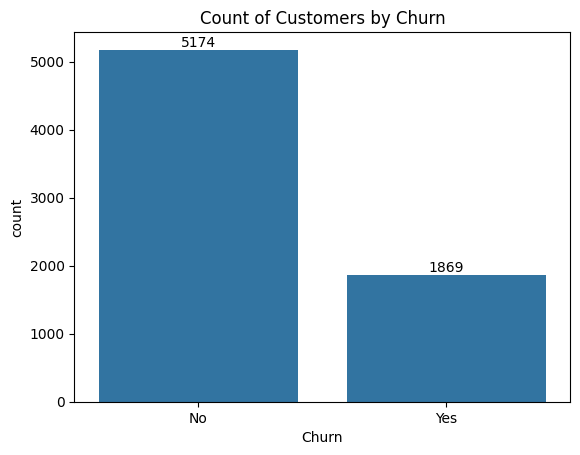

In [44]:
ax = sns.countplot(x="Churn", data=df)

ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn")
plt.show()

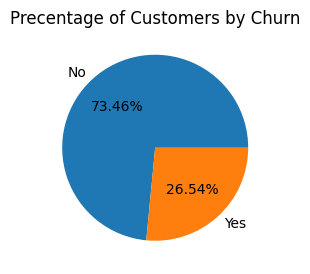

In [45]:
plt.figure(figsize=(3,4))
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb["Churn"], labels=gb.index, autopct='%.2f%%')
plt.title("Precentage of Customers by Churn")
plt.show()

### From the above pie chart we can see that 26.54% of our Cutomers have Churned out  

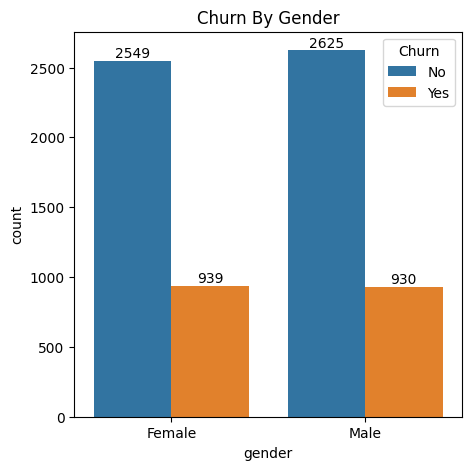

In [46]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x="gender", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn By Gender")
plt.show()

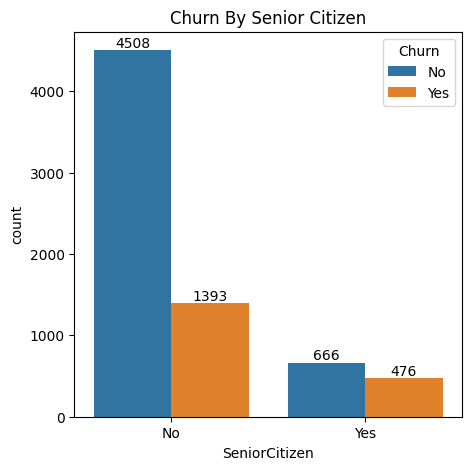

In [47]:
plt.figure(figsize=(5,5))
ax = sns.countplot(x="SeniorCitizen", data=df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn By Senior Citizen")
plt.show()

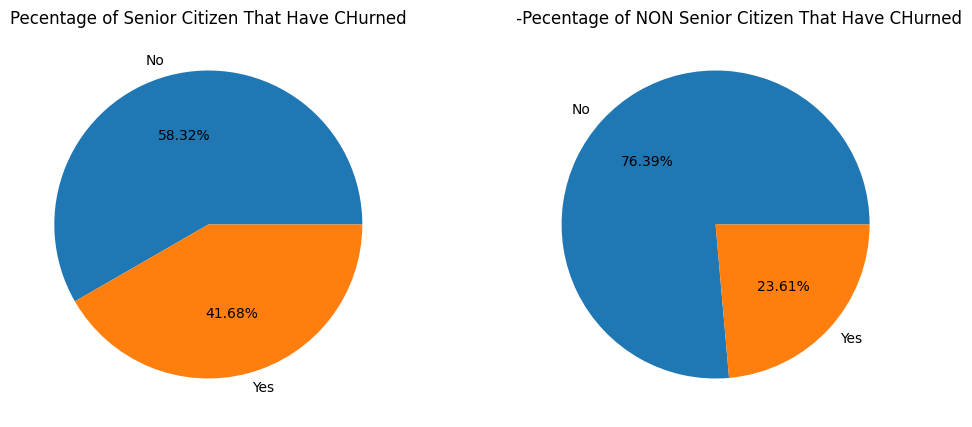

In [53]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

gb = df[df["SeniorCitizen"]=="Yes"].groupby("Churn").agg({"Churn":"count"})

axes[0].pie(gb["Churn"], labels=gb.index, autopct="%.2f%%")
axes[0].set_title("Pecentage of Senior Citizen That Have CHurned")


gb = df[df["SeniorCitizen"]=="No"].groupby("Churn").agg({"Churn":"count"})

axes[1].pie(gb["Churn"], labels=gb.index, autopct="%.2f%%")
axes[1].set_title("         -Pecentage of NON Senior Citizen That Have CHurned")
plt.show()
# plt.show()

##### From The above 2 pie charts we can notice that a greater percentage of Senior Citizens Churn as Compared to Non-Senior Citizens 

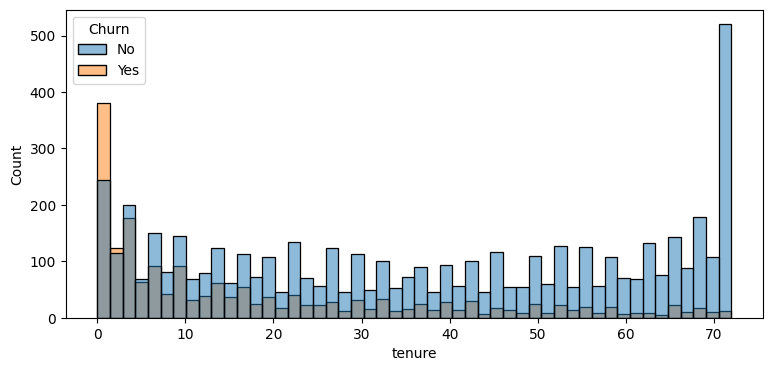

In [54]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure", data=df, bins=50, hue="Churn")
plt.show()

### Maximum Number of People who have stayed with the company for a longer tenure have not churned out and those People who have Tenure Period of less than 3 months have Churned the Max

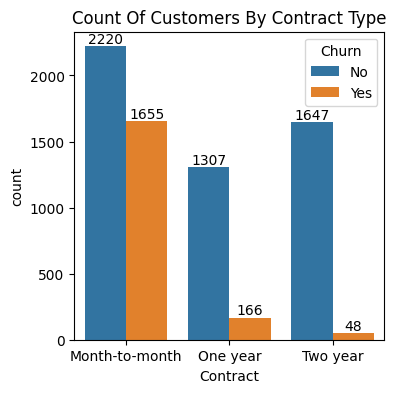

In [55]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="Contract", data=df, hue="Churn")

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title("Count Of Customers By Contract Type")
plt.show()

<Figure size 500x1500 with 0 Axes>

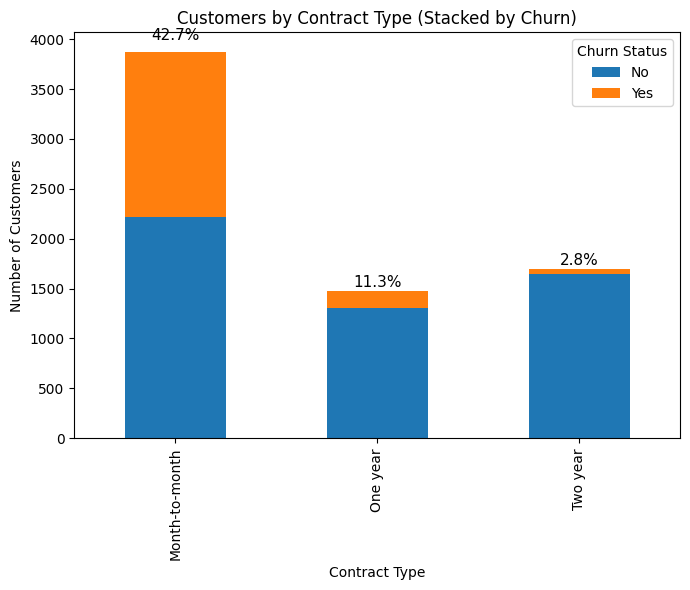

In [56]:
plt.figure(figsize=(5,15))

contract_churn = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)

# Identify churned category (the one indicating positive churn)
# Common churn labels
possible_churn_labels = ["Yes", "yes", "Y", "y", "True", True, 1, "1", "Churn", "Churned"]

churn_col = None
for col in contract_churn.columns:
    if col in possible_churn_labels:
        churn_col = col

# If nothing matches, assume the LAST column is churned
if churn_col is None:
    churn_col = contract_churn.columns[-1]

# Step 2: Compute churn percentage
contract_churn["Churn %"] = (
    contract_churn[churn_col] / contract_churn.sum(axis=1) * 100
)

# Step 3: Plot stacked bar chart automatically
contract_churn.drop(columns=["Churn %"]).plot(
    kind="bar",
    stacked=True,
    figsize=(7, 6)
)

plt.title("Customers by Contract Type (Stacked by Churn)")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn Status")

# Step 4: Add % churn labels above bars
for i, (total, pct) in enumerate(zip(contract_churn.sum(axis=1), contract_churn["Churn %"])):
    plt.text(
        i,
        total + total * 0.02,
        f"{pct:.1f}%",
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Cusomers using month-to-month Contract Type are Highly Likely to Churn ( churn rate of 42%) compared to Cusotmers with One Year (Churn rate of 11.2%) or Two Year Contrat Types (Churn rate of 2.8%)

In [57]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

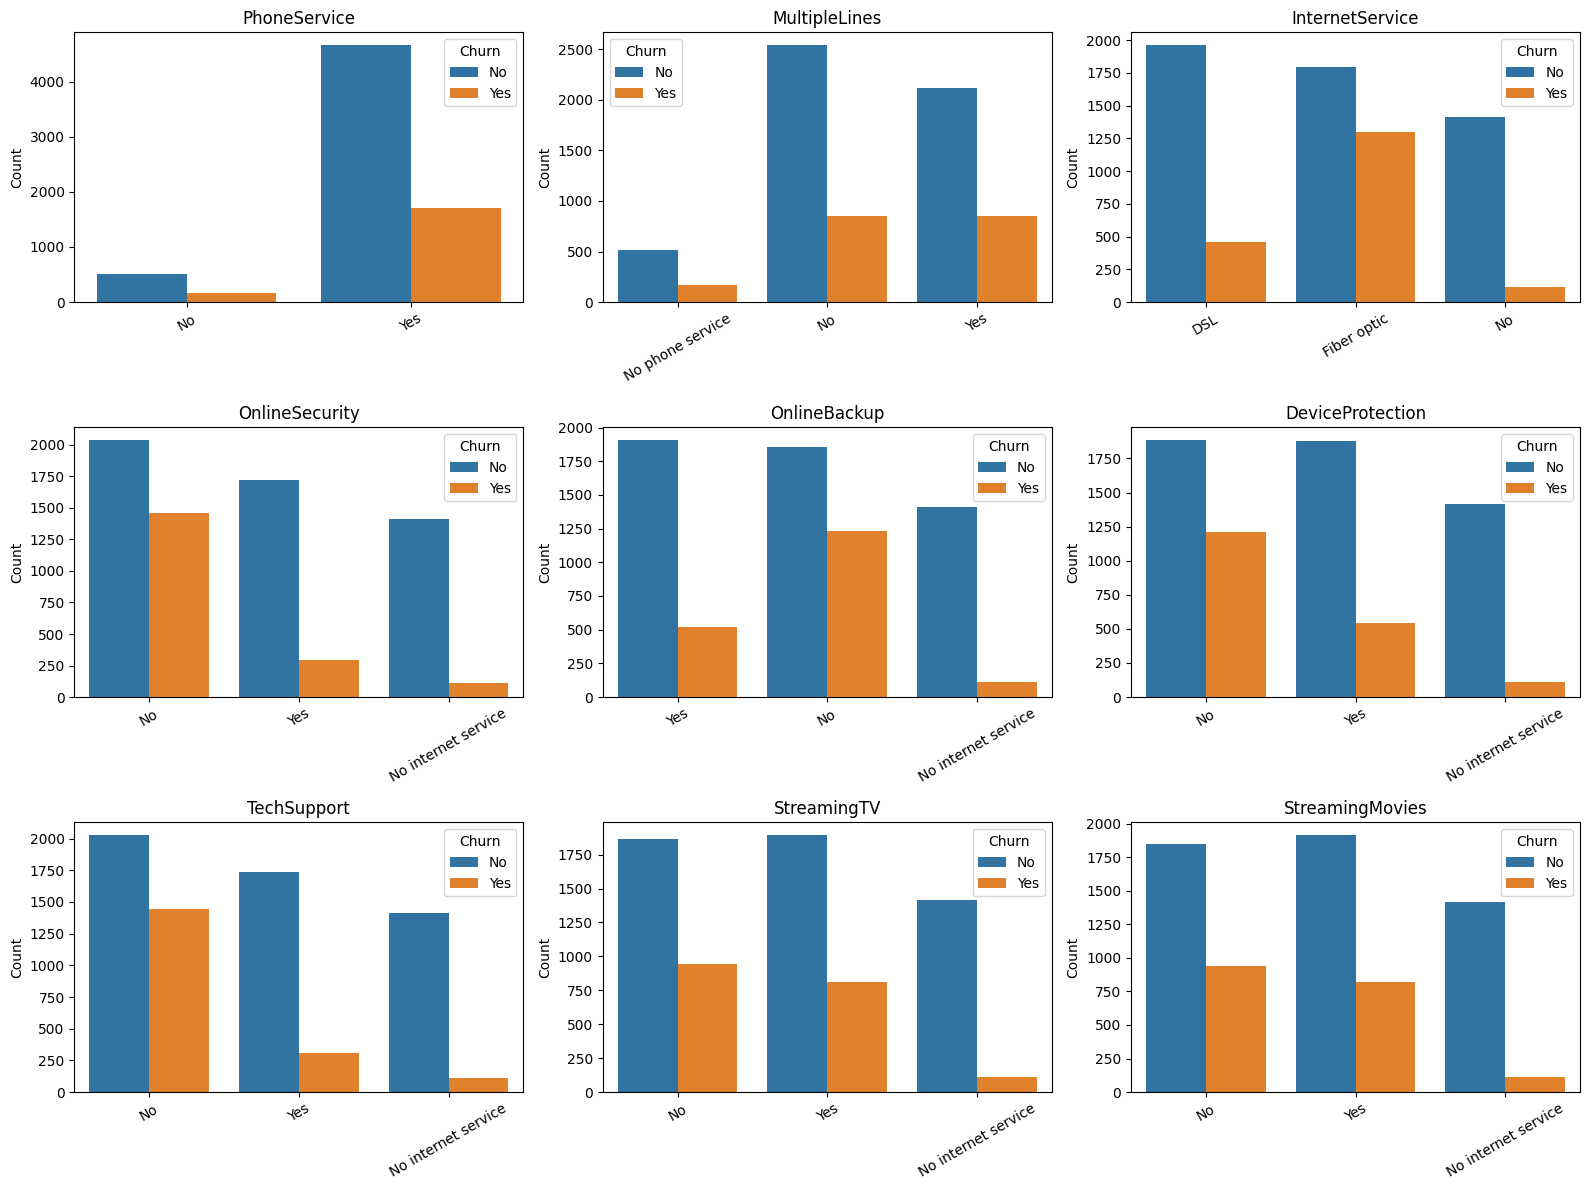

In [58]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Determine subplot grid automatically (3 columns layout)
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(16, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    ax = sns.countplot(data=df, x=col, hue=df["Churn"])
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Overall pattern: churn is concentrated in feature-rich, high-value plans

#### What we see (across all charts):
#### Churn is not driven by “light” users with no services. It’s concentrated in:
> #### Fiber internet
> #### Streaming users
> #### Multi-line users
> #### Customers without security/support add-ons.

#### So what (executive summary):
#### Your highest-revenue cohorts are also where you’re leaking the most customers.

#### The commercial focus should be:
> #### Defend high-value fiber + streaming + multi-line customers with better bundles, clearer pricing, and proactive care.
> #### Increase stickiness via security/backup/support add-ons, at least for at-risk segments.
> #### Use “no internet” / low-feature users for safe cross-sell, not for churn firefighting.


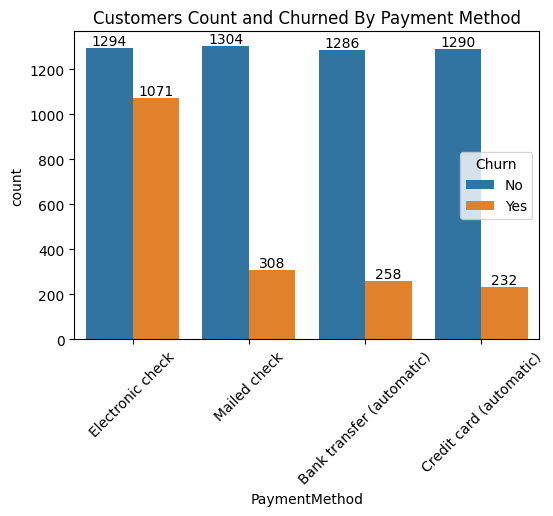

In [59]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="PaymentMethod", data=df, hue="Churn")

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.set_title("Customers Count and Churned By Payment Method")
plt.xticks(rotation=45)
plt.show()

### Customers using Electronic Check Churn the Highest with Churn Rate of almost 40% where as other payment methods have Churn Rate Not more than around 15%

# **EFFECT OF REDUCED CHURN ON REVENUE :**

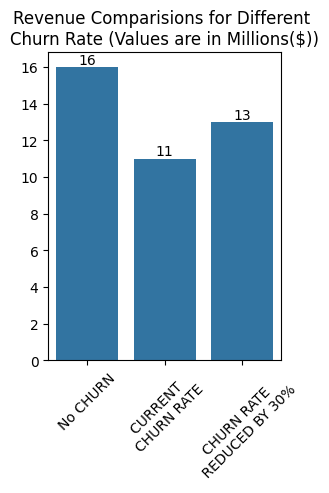

In [60]:
n_customers = df["customerID"].nunique()
total_revenue = df["TotalCharges"].sum() 
avg_rev_per_customer = total_revenue // n_customers

churned_cust = df[df["Churn"]=="Yes"]["customerID"].nunique()
not_churned_cust = df[df["Churn"]=="No"]["customerID"].nunique()
current_churn_rate = (churned_cust / n_customers) * 100

total_revenue_after_churn =  avg_rev_per_customer * ( n_customers * (1-(current_churn_rate /100))) 

# IF The Churn Rate is reduced by 30%
expeceted_churn_rate = current_churn_rate  * 0.70

new_customers = n_customers * (1- (expeceted_churn_rate/100))

revenue_after_reducing_churn =  avg_rev_per_customer * new_customers 

scenarios = ["No CHURN", "CURRENT \nCHURN RATE", "CHURN RATE\n REDUCED BY 30%"]
revenues = [total_revenue//1000000, total_revenue_after_churn//1000000, revenue_after_reducing_churn//1000000]


plt.figure(figsize=(3,4))

ax = sns.barplot(x=scenarios, y=revenues)
ax.set_title("Revenue Comparisions for Different \nChurn Rate (Values are in Millions($))")

plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
# plt.bar(scenarios, revenues)

plt.show()

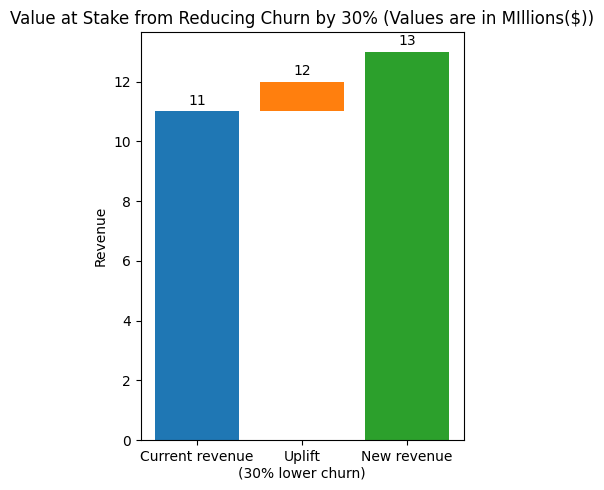

In [61]:
base = total_revenue_after_churn//1000000
uplift = (revenue_after_reducing_churn - total_revenue_after_churn)//1000000
final = revenue_after_reducing_churn//1000000

labels = ["Current revenue", "Uplift\n(30% lower churn)", "New revenue"]
values = [base, uplift, final]

# for waterfall, we plot cumulative
cumulative = [base, base + uplift, final]

plt.figure(figsize=(4,5))

# bar positions
x = np.arange(len(labels))

# bars: first is base, second is uplift, third is final level
plt.bar(0, base)
plt.bar(1, uplift, bottom=base)
plt.bar(2, final)

for i, v in enumerate(cumulative):
    plt.text(i, v*1.01, f"{v:,.0f}", ha='center', va='bottom', fontsize=10)

plt.xticks(x, labels)
plt.ylabel("Revenue")
plt.title("Value at Stake from Reducing Churn by 30% (Values are in MIllions($))")
plt.tight_layout()
plt.show()